C:\Users\dell\AppData\Local\Temp\ipykernel_11208\1208351008.py:115: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort = df.groupby('TenureGroup')['Churn_Flag'].mean() * 100


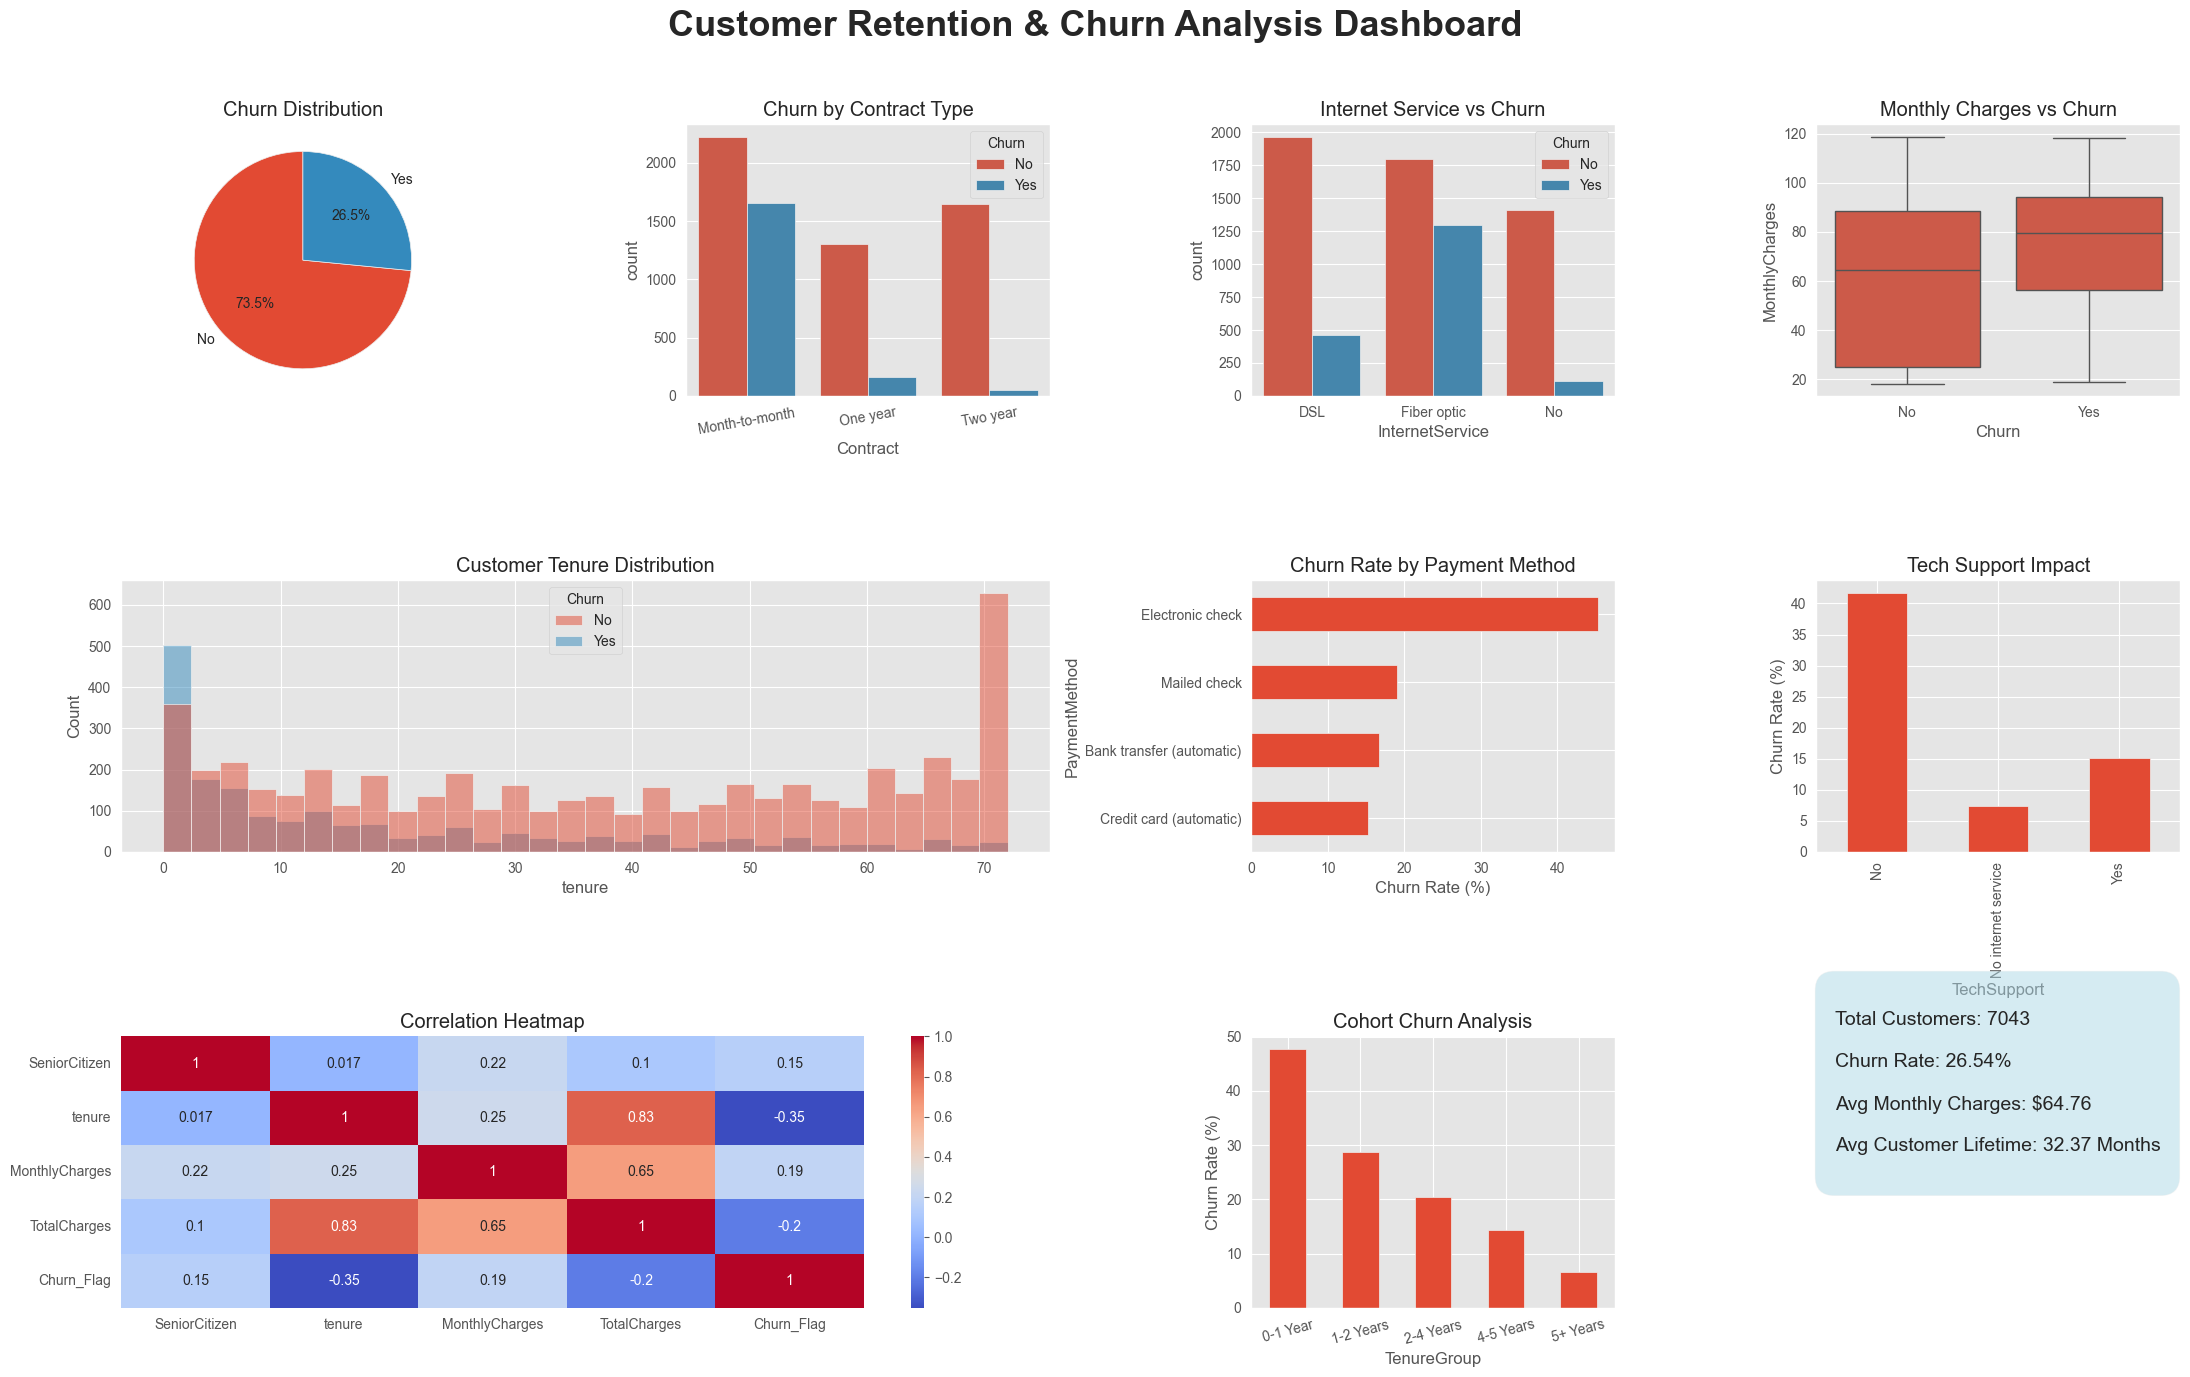

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

df = pd.read_csv("data/Cleaned-Telco-Customer-Churn.csv")

# Dashboard Style

sns.set_style('whitegrid')
plt.style.use('ggplot')

# Create Figure

fig = plt.figure(figsize=(22, 14))
fig.suptitle('Customer Retention & Churn Analysis Dashboard', fontsize=26, fontweight='bold')

# ---------------------------------------------------
# KPI Calculations
# ---------------------------------------------------

total_customers = len(df)
churn_rate = df['Churn_Flag'].mean() * 100
avg_monthly = df['MonthlyCharges'].mean()
avg_tenure = df['tenure'].mean()

# ---------------------------------------------------
# 1. Churn Distribution
# ---------------------------------------------------

ax1 = plt.subplot2grid((3,4), (0,0))
churn_counts = df['Churn'].value_counts()
ax1.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90)
ax1.set_title('Churn Distribution')

# ---------------------------------------------------
# 2. Contract Type Analysis
# ---------------------------------------------------

ax2 = plt.subplot2grid((3,4), (0,1))
sns.countplot(data=df, x='Contract', hue='Churn', ax=ax2)
ax2.set_title('Churn by Contract Type')
ax2.tick_params(axis='x', rotation=10)

# ---------------------------------------------------
# 3. Internet Service Analysis
# ---------------------------------------------------

ax3 = plt.subplot2grid((3,4), (0,2))
sns.countplot(data=df, x='InternetService', hue='Churn', ax=ax3)
ax3.set_title('Internet Service vs Churn')

# ---------------------------------------------------
# 4. Monthly Charges Analysis
# ---------------------------------------------------

ax4 = plt.subplot2grid((3,4), (0,3))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=ax4)
ax4.set_title('Monthly Charges vs Churn')

# ---------------------------------------------------
# 5. Tenure Distribution
# ---------------------------------------------------

ax5 = plt.subplot2grid((3,4), (1,0), colspan=2)
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, ax=ax5)
ax5.set_title('Customer Tenure Distribution')

# ---------------------------------------------------
# 6. Payment Method Churn
# ---------------------------------------------------

ax6 = plt.subplot2grid((3,4), (1,2))
payment_churn = df.groupby('PaymentMethod')['Churn_Flag'].mean() * 100
payment_churn.sort_values().plot(kind='barh', ax=ax6)
ax6.set_title('Churn Rate by Payment Method')
ax6.set_xlabel('Churn Rate (%)')

# ---------------------------------------------------
# 7. Tech Support Impact
# ---------------------------------------------------

ax7 = plt.subplot2grid((3,4), (1,3))
tech_support = df.groupby('TechSupport')['Churn_Flag'].mean() * 100
tech_support.plot(kind='bar', ax=ax7)
ax7.set_title('Tech Support Impact')
ax7.set_ylabel('Churn Rate (%)')

# ---------------------------------------------------
# 8. Correlation Heatmap
# ---------------------------------------------------

ax8 = plt.subplot2grid((3,4), (2,0), colspan=2)

numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Flag']

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', ax=ax8)
ax8.set_title('Correlation Heatmap')

# ---------------------------------------------------
# 9. Tenure Group Cohort Analysis
# ---------------------------------------------------

ax9 = plt.subplot2grid((3,4), (2,2))

bins = [0,12,24,48,60,72]
labels = ['0-1 Year','1-2 Years','2-4 Years','4-5 Years','5+ Years']

df['TenureGroup'] = pd.cut(df['tenure'], bins=bins, labels=labels)

cohort = df.groupby('TenureGroup')['Churn_Flag'].mean() * 100

cohort.plot(kind='bar', ax=ax9)
ax9.set_title('Cohort Churn Analysis')
ax9.set_ylabel('Churn Rate (%)')
ax9.tick_params(axis='x', rotation=15)

# ---------------------------------------------------
# 10. KPI Summary Box
# ---------------------------------------------------

ax10 = plt.subplot2grid((3,4), (2,3))
ax10.axis('off')

kpi_text = f'''
Total Customers: {total_customers}

Churn Rate: {churn_rate:.2f}%

Avg Monthly Charges: ${avg_monthly:.2f}

Avg Customer Lifetime: {avg_tenure:.2f} Months
'''

ax10.text(
    0.05,
    0.5,
    kpi_text,
    fontsize=14,
    bbox=dict(facecolor='lightblue', alpha=0.5, boxstyle='round,pad=1')
)

# ---------------------------------------------------
# Final Layout
# ---------------------------------------------------

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save Dashboard
plt.savefig('customer_churn_dashboard.png', dpi=300, bbox_inches='tight')

# Show Dashboard
plt.show()